In [1]:
pwd()


"/home/nicholaswallace/Documents/projects/Polyhedron"

In [1]:
using Pkg
Pkg.activate(".")
Pkg.instantiate()
include("Polyhedron.jl")
using .Poly

  Activating project at `~/Documents/projects/Polyhedron`
┌ Warning: Make sure you comply with the NEOS terms of use: http://www.neos-server.org/neos/termofuse.html
└ @ NEOSServer ~/.julia/packages/NEOSServer/2P7PD/src/NEOSServer.jl:14


In [2]:
Pkg.status()

Status `~/Documents/projects/Polyhedron/Project.toml`
⌃ [3391f64e] CDDLib v0.10.1
  [8bb1440f] DelimitedFiles v1.9.1
⌃ [87dc4568] HiGHS v1.20.1
  [7073ff75] IJulia v1.34.4
⌃ [4076af6c] JuMP v1.29.3
  [b8f27783] MathOptInterface v1.49.0
  [f10290a3] NEOSServer v1.2.0
⌃ [91a5bcdd] Plots v1.41.1
  [67491407] Polyhedra v0.8.1
  [37e2e46d] LinearAlgebra v1.12.0
Info Packages marked with ⌃ have new versions available and may be upgradable.


In [3]:
A = [0.9666 0;
    0.0328 0.9666] 
B = [0.1980;
    0.0033;;]

C = [0 1]

T = 0.5

delta = 0.5

A_exp = hcat(A, [0 0; 0 0])
A_exp = vcat(A_exp, [0 -T 1 T; 0 0 0 delta])

B_exp = vcat(B, [0;0])

E_exp = vcat(zeros(3), [1-delta])

Sx = [1/15 0
      0 1/15;
     -1/15 0;
      0 -1/15;]
Sv = [1/300;
      -1/300;]

Sw = [1/50;
      -1/50;]

Sx = vcat(Sx, zeros(4, 2))
Sv = vcat(vcat(zeros(4, 1), Sv) , zeros(2, 1))
Sw = vcat(zeros(6, 1), Sw)

S = hcat(hcat(Sx, Sv), Sw)

# Fr para a referência
R = [1/15;
      -1/15;]

2-element Vector{Float64}:
  0.06666666666666667
 -0.06666666666666667

X[k+1] = (A+BK)X[k] + Er[1]

In [3]:
result = Poly.finding_pinvariant_segref(A_exp, B_exp, E_exp, S, R; lambda=0.99, ll = 20)

Job 18587698 dispatched
password: LjaAcNYw
---------- Begin Solver Output -----------
Condor submit: 'neos.submit'
Condor submit: 'watchdog.submit'
Job submitted to NEOS HTCondor pool.

OTHER_LIMIT

Dict{String, Matrix{Float64}} with 2 entries:
  "L" => [0.0105946 0.463173 -0.022226 -0.0109801; 0.00436457 0.161402 -0.00601…
  "K" => [-6.34381 -81.3993 4.16666 4.17238]

In [ ]:
L = result["L"]
K = result["K"]
w = ones(size(L, 1))

av = eigvals(A_exp + B_exp*K)

L1 = L[:, 1:2]
L2 = L[:, 3:4]

T = Poly.poly_projection(L2)

L_proj = T * L1
w_proj = T * w

4-element Vector{Float64}:
 -1.944865383907146e-5
  0.5
  0.8763646363308355
  0.9699961473903257

In [12]:
function trajectory_segref(x0, A, E, r, passos)
    for i in range(2, passos)
        try
            x0 = hcat(x0, A*x0[:, i-1] + E*r[i-1])    
        catch e
            print(e)
        end
        
    end
    return x0   
end

N = 200

r1 = 10*ones(N)

x0 = [0; 0; 0; 0]
x = trajectory_segref(x0, A_exp + B_exp*K, E_exp, r1, N)

4×200 Matrix{Float64}:
 0.0  0.0  1.117      2.09722    …   10.0096    10.0097    10.0098
 0.0  0.0  0.0186167  0.0715914       9.96681    9.96781    9.96878
 0.0  0.0  2.5        6.24069       198.991    199.008    199.024
 0.0  5.0  7.5        8.75           10.0       10.0       10.0

In [68]:
size(x)
x[:, N]

4-element Vector{Float64}:
   9.998187405466428
   9.856781311734023
 197.1577200878052
  10.0

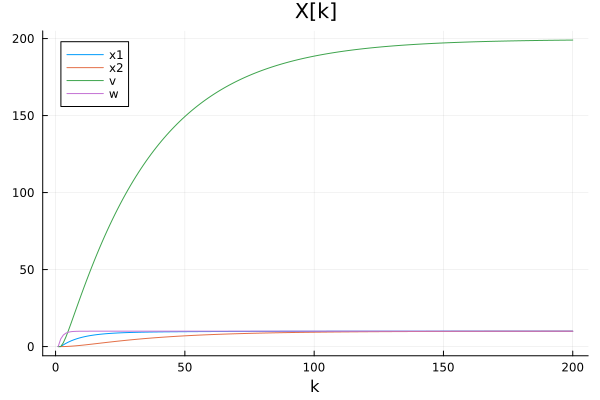

In [13]:
plot(x', 
     label=["x1" "x2" "v" "w"], 
     xlabel="k",  
     title="X[k]")

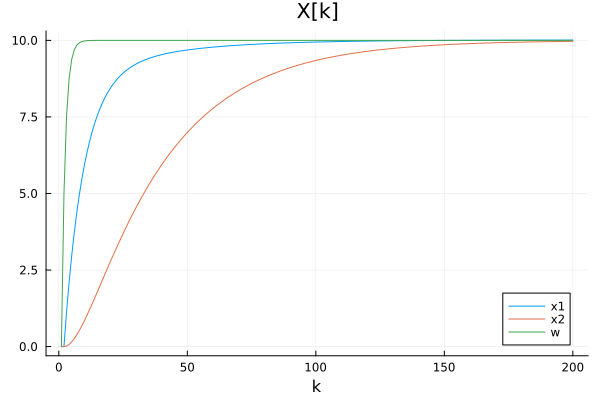

In [14]:
xw = x[1:2, :]
xw = vcat(xw, x[4, :]')

plot(xw', 
     label=["x1" "x2" "w"], 
     xlabel="k",  
     title="X[k]")


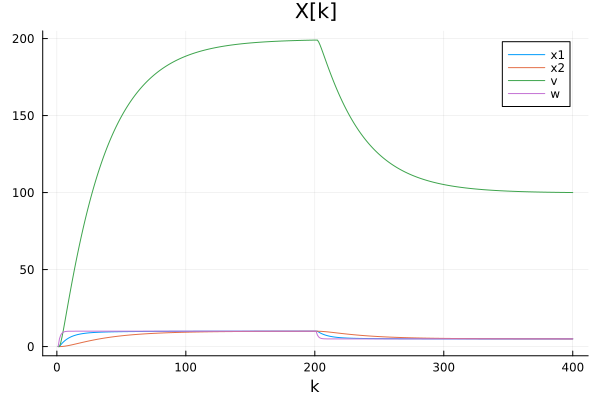

In [15]:
r2 = 5 * ones(N)
x2 = trajectory_segref(x[:, N], A_exp + B_exp*K, E_exp, r2, N)
x2 = hcat(x, x2)

plot(x2', 
     label=["x1" "x2" "v" "w"], 
     xlabel="k",  
     title="X[k]")

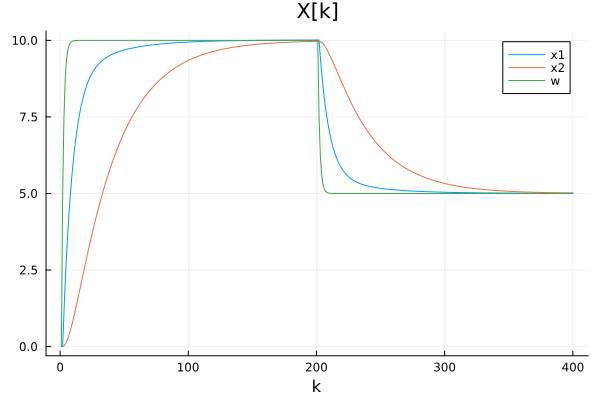

In [16]:
xw = x2[1:2, :]
xw = vcat(xw, x2[4, :]')

plot(xw', 
     label=["x1" "x2" "w"], 
     xlabel="k",  
     title="X[k]")

testando com outros valores

In [4]:
A = [0.9666 0;
    0.0328 0.9666] 
B = [0.1980;
    0.0033;;]

C = [0 1]

T = 0.5

delta = 0.5

A_exp = hcat(A, [0 0; 0 0])
A_exp = vcat(A_exp, [0 -T 1 T; 0 0 0 delta])

B_exp = vcat(B, [0;0])

E_exp = vcat(zeros(3), [1-delta])

Sx = [1/15 0
      0 1/15;
     -1/15 0;
      0 -1/15;]
Sv = [1/50;
      -1/50;]

Sw = [1/50;
      -1/50;]

Sx = vcat(Sx, zeros(4, 2))
Sv = vcat(vcat(zeros(4, 1), Sv) , zeros(2, 1))
Sw = vcat(zeros(6, 1), Sw)

S = hcat(hcat(Sx, Sv), Sw)

# Fr para a referência
R = [1/15;
      -1/15;]

2-element Vector{Float64}:
  0.06666666666666667
 -0.06666666666666667

In [ ]:
result_2 = Poly.finding_pinvariant_segref(A_exp, B_exp, E_exp, S, R; lambda=0.96, ll = 20)

In [ ]:
N = 200

r1 = 10*ones(N)

x0 = [0; 0; 0; 0]
x = trajectory_segref(x0, A_exp + B_exp*K, E_exp, r1, N)
plot(x', 
     label=["x1" "x2" "v" "w"], 
     xlabel="k",  
     title="X[k]")

In [5]:
F = [0.00110289  -0.0560888  -0.00175053   0.000824769;
 -0.0383211   -0.0835434  -3.1103e-14  -0.136651;
  0.0397725    0.261843   -0.0118082   -0.011876;
  0.225591     0.170398   -0.00906886   5.04668e-14;
 -0.0243287   -0.178076    0.0160696    0.0160712;
 -0.210438    -0.126352    0.00537898   0.0398989]

6×4 Matrix{Float64}:
  0.00110289  -0.0560888  -0.00175053   0.000824769
 -0.0383211   -0.0835434  -3.1103e-14  -0.136651
  0.0397725    0.261843   -0.0118082   -0.011876
  0.225591     0.170398   -0.00906886   5.04668e-14
 -0.0243287   -0.178076    0.0160696    0.0160712
 -0.210438    -0.126352    0.00537898   0.0398989

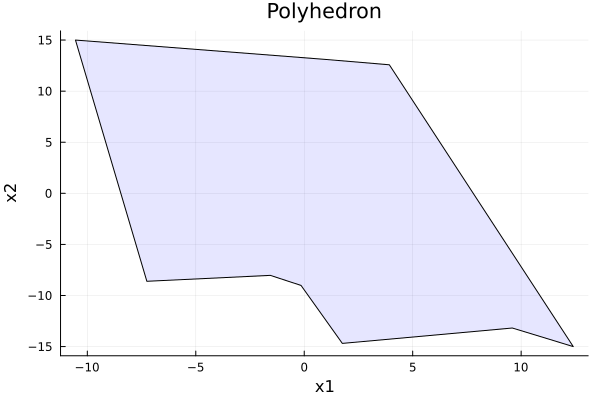

In [6]:
Poly.plot_poly(F, ones(6))

In [17]:
T = Poly.poly_projection(F[:,3:4])

8×6 Matrix{Float64}:
 0.014669  0.0        0.567053  0.0         0.418278   0.0
 0.886697  0.0167116  0.0       0.0         0.0965916  0.0
 0.701019  0.0708423  0.0       0.0         0.0        0.228139
 0.0       0.147775   0.266716  0.0         0.0        0.585509
 0.0       0.0        0.576004  0.0         0.422885   0.00111172
 0.0       0.0407009  0.0       0.613226    0.346073   0.0
 0.0       0.0        0.572637  0.00420645  0.423157   0.0
 0.0       0.154886   0.0       0.314639    0.0        0.530475

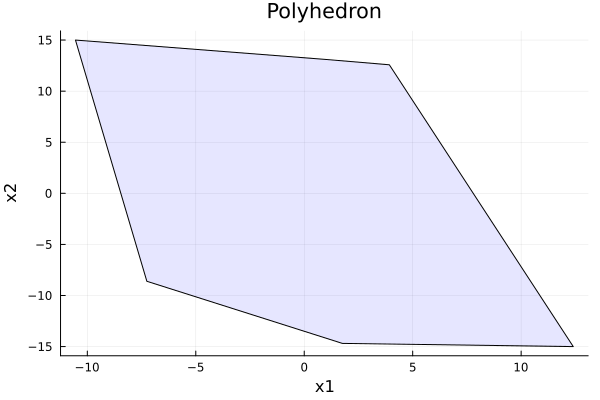

In [21]:
Poly.plot_poly(T*F[:,1:2], T*ones(6))